In [2]:
@njit
def _compute_h_core(w1, w2, w3, r, h0):
    """Compute the conditional-variance path h_t of a GARCH(1,1)
    model from a returns series r, starting from h_0 = h0.

    Returns the (T,) array of variances h_t.
    """
    T = len(r)
    h = np.empty(T)

    h[0] = h0

    for t in range(1, T):
        h[t] = w1 + w2 * r[t - 1] ** 2 + w3 * h[t - 1]

    return h

@njit
def _initial_h(w1, w2, w3, r):
    """Initial conditional variance h_0.

    Uses the stationary variance w1 / (1 - w2 - w3) when admissible,
    otherwise the empirical variance.
    """
    if (1.0 - w2 - w3) > 1e-8:
        return w1 / (1.0 - w2 - w3)

    return np.var(r)

@njit
def _log_lik_core(w1, w2, w3, r):
    """Gaussian log-likelihood of a GARCH(1,1) model:

    ln L(r | w) = -0.5 * sum_t [ln(h_t) + r_t^2 / h_t],
    up to the constant -T/2 * ln(2*pi).

    Reuses `_compute_h_core` to build the (h_t) sequence, then sums the
    per-observation Gaussian log-densities. Returns -inf if any h_t <= 0
    for numerical safety.
    """
    h0 = _initial_h(w1, w2, w3, r)

    if h0 <= 0:
        return -np.inf

    h = _compute_h_core(w1, w2, w3, r, h0)
    loglik = 0.0

    for t in range(len(r)):
        if h[t] <= 0:
            return -np.inf

        loglik -= 0.5 * (np.log(h[t]) + r[t] ** 2 / h[t])

    return loglik

@njit
def _grad_log_lik_core(w1, w2, w3, r):
    """Analytical gradient of ln L(r | w) w.r.t. (w1, w2, w3), in three
    clearly separated passes (no numerical differentiation):

    Step 1. Compute the (h_t) sequence via `_compute_h_core`.
    Step 2. Compute the three derivative sequences dh_t/dw_k using the
            recursions obtained by differentiating the GARCH recurrence
            h_t = w1 + w2*r_{t-1}^2 + w3*h_{t-1}:
                dh_t/dw1 = 1           + w3 * dh_{t-1}/dw1
                dh_t/dw2 = r_{t-1}^2  + w3 * dh_{t-1}/dw2
                dh_t/dw3 = h_{t-1}    + w3 * dh_{t-1}/dw3
            with initial conditions obtained by differentiating
            h_0 = w1 / (1 - w2 - w3).
    Step 3. Apply the chain rule and sum:
            d(log-lik)/dw_k = -0.5 * sum_t (1/h_t) * (1 - r_t^2/h_t)

    Returns a tuple (g1, g2, g3).
    """
    T = len(r)
    one_minus_sum = 1.0 - w2 - w3

    # Step 1: h_t sequence
    h0 = _initial_h(w1, w2, w3, r)
    h = _compute_h_core(w1, w2, w3, r, h0)

    # Step 2: dh_t/dw_k for k = 1, 2, 3
    dh_dw1 = np.empty(T)
    dh_dw2 = np.empty(T)
    dh_dw3 = np.empty(T)
    if one_minus_sum > 1e-8:
        dh_dw1[0] = 1.0 / one_minus_sum
        dh_dw2[0] = w1 / one_minus_sum ** 2
        dh_dw3[0] = w1 / one_minus_sum ** 2
    else:
        dh_dw1[0] = 0.0
        dh_dw2[0] = 0.0
        dh_dw3[0] = 0.0
    for t in range(1, T):
        dh_dw1[t] = 1.0              + w3 * dh_dw1[t - 1]
        dh_dw2[t] = r[t - 1] ** 2   + w3 * dh_dw2[t - 1]
        dh_dw3[t] = h[t - 1]        + w3 * dh_dw3[t - 1]

    # Step 3: chain rule + sum
    g1 = 0.0
    g2 = 0.0
    g3 = 0.0
    for t in range(T):
        coef = -0.5 * (1.0 / h[t]) * (1.0 - r[t] ** 2 / h[t])
        g1 += coef * dh_dw1[t]
        g2 += coef * dh_dw2[t]
        g3 += coef * dh_dw3[t]
    return g1, g2, g3

@njit
def _simulate_garch_core(w1, w2, w3, T, noise):
    """simulate one GARCH(1,1) trajectory of length T given pre-drawn
    standard-normal noise. Starts from the stationary variance
    h_0 = w1 / (1 - w2 - w3), then iterates h_t = w1 + w2*r_{t-1}^2 + w3*h_{t-1}
    and r_t = sqrt(h_t) * noise_t. Returns the (T,) array of returns r_t.
    """
    r = np.empty(T)
    h = np.empty(T)

    h[0] = w1 / (1.0 - w2 - w3)
    r[0] = np.sqrt(h[0]) * noise[0]

    for t in range(1, T):
        h[t] = w1 + w2 * r[t - 1] ** 2 + w3 * h[t - 1]
        r[t] = np.sqrt(h[t]) * noise[t]

    return r


def simulate_garch(omega, T, rng):
    """
    Simulate a GARCH(1,1) trajectory of length T.

    Parameters
    ----------
    omega : array-like of shape (3,)
        GARCH parameters (w1, w2, w3), must satisfy w1>0, w2,w3>=0, w2+w3<1
    T : int
        Length of the series
    rng : numpy.random.Generator
        Random-number generator used to draw the standard-normal innovations

    Returns
    -------
    r : np.ndarray of shape (T,)
        Simulated returns.
    """
    w1, w2, w3 = omega
    assert w1 > 0 and w2 >= 0 and w3 >= 0 and (w2 + w3) < 1
    noise = rng.standard_normal(T)
    return _simulate_garch_core(float(w1), float(w2), float(w3), int(T), noise)

class Prior:
    """Truncated-Gaussian prior pi_0(w) on (w1, w2, w3).
    Each component w_k is a priori Gaussian with mean m[k] and variance
    s2[k], restricted to the admissible region {w1>0, w2,w3>=0, w2+w3<1}.
    Only the mean and variance are stored; the truncation is enforced by
    valid(omega) in log_posterior.
    """

    def __init__(self, m, s2):
        self.m = m
        self.s2 = s2

    def __repr__(self):
        return f"Prior(m={self.m!r}, s2={self.s2!r})"

    @staticmethod
    def default():
        """Weakly informative default: m=0, s^2=100 for each component."""
        return Prior(m=np.zeros(3), s2=np.full(3, 100.0))


def all_z(chain, r, prior):
    """Compute the control variate z at every state of a chain.

    Parameters
    ----------
    chain : np.ndarray of shape (N, 3)
        MCMC chain of omega states.
    r : np.ndarray
        Observed returns (used in the likelihood).
    prior : Prior
        Prior for the Gaussian gradient correction.

    Returns
    -------
    Z : np.ndarray of shape (N, 3)
        Z[i] = -0.5 * grad ln tilde pi(chain[i]).
    """
    N = chain.shape[0]
    Z = np.empty((N, 3))
    for i in range(N):
        g0, g1, g2 = _grad_log_lik_core(
            float(chain[i, 0]), float(chain[i, 1]), float(chain[i, 2]), r
        )
        Z[i, 0] = -0.5 * (g0 - (chain[i, 0] - prior.m[0]) / prior.s2[0])
        Z[i, 1] = -0.5 * (g1 - (chain[i, 1] - prior.m[1]) / prior.s2[1])
        Z[i, 2] = -0.5 * (g2 - (chain[i, 2] - prior.m[2]) / prior.s2[2])
    return Z

@njit
def _rwm_core(r, n_iter, burn_in, omega0, L, m, s2, noise, u):
    """JIT core: Random Walk Metropolis main loop.

    Runs `burn_in + n_iter` iterations starting at omega0 with proposal
    omega' = omega + L @ eps, eps ~ N(0, I_3), where L is the Cholesky factor
    of Sigma_prop. At each step the log-acceptance ratio lp_prop - lp is
    compared to ln(u[it]); invalid proposals (out of admissibility) are
    automatically rejected via lp_prop = -inf. Only the post-burn-in states
    are stored in `chain`.

    Inputs `noise` (shape (total, 3)) and `u` (shape (total,)) are pre-drawn
    by the Python wrapper because numba does not support numpy Generator.

    Returns the chain (shape (n_iter, 3)) and the post-burn-in acceptance
    count `n_acc`.
    """
    d = 3
    chain = np.empty((n_iter, d))

    omega = omega0.copy()
    w1, w2, w3 = omega[0], omega[1], omega[2]

    if (w1 <= 0) or (w2 < 0) or (w3 < 0) or (w2 + w3 >= 0.999):
        lp = -np.inf
    else:
        lp = _log_lik_core(w1, w2, w3, r) - 0.5 * (
            (w1 - m[0]) ** 2 / s2[0]
            + (w2 - m[1]) ** 2 / s2[1]
            + (w3 - m[2]) ** 2 / s2[2]
        )

    n_acc = 0
    total = n_iter + burn_in

    for it in range(total):
        eps = L @ noise[it]
        prop = omega + eps

        pw1, pw2, pw3 = prop[0], prop[1], prop[2]

        if (pw1 <= 0) or (pw2 < 0) or (pw3 < 0) or (pw2 + pw3 >= 0.999):
            lp_prop = -np.inf
        else:
            ll = _log_lik_core(pw1, pw2, pw3, r)

            if not np.isfinite(ll):
                lp_prop = -np.inf
            else:
                lp_prop = ll - 0.5 * (
                    (pw1 - m[0]) ** 2 / s2[0]
                    + (pw2 - m[1]) ** 2 / s2[1]
                    + (pw3 - m[2]) ** 2 / s2[2]
                )

        log_alpha = lp_prop - lp

        if np.log(u[it]) < log_alpha:
            omega = prop
            lp = lp_prop

            if it >= burn_in:
                n_acc += 1

        if it >= burn_in:
            chain[it - burn_in] = omega

    return chain, n_acc


def rwm(r, prior, n_iter, omega0, Sigma_prop, rng, burn_in=0):
    """High-level Random Walk Metropolis sampler.

    Parameters
    ----------
    r : np.ndarray
        Observed returns.
    prior : Prior
        Gaussian prior on (w1, w2, w3).
    n_iter : int
        Number of post-burn-in iterations to keep.
    omega0 : np.ndarray of shape (3,)
        Initial state of the chain (must satisfy admissibility constraints).
    Sigma_prop : np.ndarray of shape (3, 3)
        Proposal covariance (positive-definite).
    rng : numpy.random.Generator
        Random generator for the proposal noise and the uniform acceptance draws.
    burn_in : int, default 0
        Number of iterations discarded at the beginning of the run.

    Returns
    -------
    chain : np.ndarray of shape (n_iter, 3)
        The post-burn-in sequence of omega states.
    acc_rate : float
        Empirical acceptance rate over the post-burn-in iterations.
    """
    L = np.linalg.cholesky(Sigma_prop)
    total = n_iter + burn_in

    noise = rng.standard_normal((total, 3))
    u = rng.uniform(size=total)

    chain, n_acc = _rwm_core(
        r,
        n_iter,
        burn_in,
        omega0.astype(float),
        L,
        prior.m,
        prior.s2,
        noise,
        u,
    )

    return chain, n_acc / n_iter

 
def adaptive_rwm(r, prior, n_iter, omega0, rng, pilot_iter=2000, burn_in=0):
    """Adaptive RWM with Roberts-Gelman-Gilks pilot calibration.

    Runs a first *pilot* chain with a rough diagonal proposal to get a
    preliminary sample of the posterior, estimates its empirical covariance
    Sigma_hat on the second half, then sets Sigma_prop = (2.38^2/d) * Sigma_hat
    (optimal scaling, target acceptance ~0.234) and runs the main chain from
    the last pilot state.

    Returns the main chain, its acceptance rate and the tuned Sigma_prop.
    """
    d = 3

    Sigma_pilot = np.diag(np.array([1e-4, 1e-3, 1e-3]))

    pilot_chain, _ = rwm(
        r,
        prior,
        pilot_iter,
        omega0,
        Sigma_pilot,
        rng,
        burn_in=0,
    )

    half = pilot_iter // 2
    Sigma_hat = np.cov(pilot_chain[half:].T) + 1e-8 * np.eye(d)

    Sigma_prop = (2.38 ** 2 / d) * Sigma_hat
    omega_start = pilot_chain[-1].copy()

    chain, acc = rwm(
        r,
        prior,
        n_iter,
        omega_start,
        Sigma_prop,
        rng,
        burn_in=burn_in,
    )

    return chain, acc, Sigma_prop


def build_controls(chain, Z, degree=2):
    """Build the design matrix W of control variates for a polynomial trial
    function of degree 1 or 2, following Mira, Solgi & Imparato (2013).

    For d = 3 (our GARCH case):
    - degree 1 -> 3 columns:   z_j                               for j = 1, 2, 3
    - degree 2 -> 9 columns:   z_j                               (3 linear)
                               omega_i*z_i - 1/2                 (3 diagonal quadratic)
                               omega_i*z_j + omega_j*z_i, i<j   (3 symmetric cross terms)

    The diagonal correction -1/2 comes from the -1/2 tr(B) term in the
    renormalised function. Each column has E_pi[.] = 0 on R^d by integration
    by parts, which gives asymptotic unbiasedness of the ZV-OLS estimator.

    Returns
    -------
    W : np.ndarray of shape (N, n_cols)
        Design matrix; each row corresponds to one state of the chain.
    """
    chain = np.asarray(chain); Z = np.asarray(Z)
    N, d = chain.shape
    cols = [Z[:, j] for j in range(d)]  # linear terms z_j
    if degree >= 2:
        # Diagonal quadratic terms: omega_i*z_i - 1/2
        for i in range(d):
            cols.append(chain[:, i] * Z[:, i] - 0.5)
        # Symmetric off-diagonal terms: omega_i*z_j + omega_j*z_i, i < j
        for i in range(d):
            for j in range(i + 1, d):
                cols.append(chain[:, i] * Z[:, j] + chain[:, j] * Z[:, i])
    return np.column_stack(cols)


def zv_estimator_ols(f_vals, W):
    """Zero-Variance estimator with OLS choice of coefficients.

    Regresses f(omega^{i}) on W^{i} (design matrix of control variates, with
    an added intercept column) to get hat beta, then returns the ZV estimator
    hat mu_tilde_f = mean(f) - hat beta[1:] @ mean(W) together with the
    regression residuals (useful for residual-variance diagnostics).
    """
    N = len(f_vals)
    Wc = np.concatenate([np.ones((N, 1)), W], axis=1)
    beta, *_ = np.linalg.lstsq(Wc, f_vals, rcond=None)
    residuals = f_vals - Wc @ beta
    mu_zv = float(np.mean(f_vals) - beta[1:] @ W.mean(axis=0))
    return mu_zv, residuals


def zv_estimator_lasso(f_vals, W, cv=3):
    """Zero-Variance estimator with LASSO-regularised coefficients.

    Standardises W, fits a LASSO with cross-validated penalty (`LassoCV`),
    then returns the ZV estimator mean(f) - beta @ mean(W) in the ORIGINAL
    (unscaled) coefficient frame. Useful in high-dimensional / collinear
    designs (high-degree polynomials) where plain OLS overfits.
    """
    scaler = StandardScaler()
    Ws = scaler.fit_transform(W)
    lasso = LassoCV(cv=cv, fit_intercept=True, max_iter=3000,
                    n_alphas=10, n_jobs=-1, tol=1e-3)
    lasso.fit(Ws, f_vals)
    coef_orig = lasso.coef_ / scaler.scale_
    mu_zv = float(np.mean(f_vals) - coef_orig @ W.mean(axis=0))
    return mu_zv


def zv_estimator_post_lasso(f_vals, W, cv=3):
    """Post-LASSO Zero-Variance estimator: use LASSO for variable selection
    only (keep variables with |coef| > 1e-10), then re-fit plain OLS on the
    selected subset. Combines the sparsity of LASSO with the unbiasedness of
    OLS on the retained model. Falls back to mean(f) if nothing is selected.
    """
    scaler = StandardScaler()
    Ws = scaler.fit_transform(W)
    lasso = LassoCV(cv=cv, fit_intercept=True, max_iter=3000,
                    n_alphas=10, n_jobs=-1, tol=1e-3)
    lasso.fit(Ws, f_vals)
    mask = np.abs(lasso.coef_) > 1e-10
    if mask.sum() == 0:
        return float(np.mean(f_vals))
    W_sel = W[:, mask]
    mu, _ = zv_estimator_ols(f_vals, W_sel)
    return mu


def effective_sample_size(x, max_lag=None):
    """Effective sample size of a scalar MCMC trajectory x.

    Computes ESS = N / (1 + 2 * sum_{k>=1} rho(k)), where rho(k) is the
    lag-k autocorrelation, summed up to the first non-positive lag
    (initial-positive-sequence truncation a la Geyer 1992). Returns N
    when the series is constant. A small ESS compared to N indicates a
    highly correlated chain.
    """
    x = np.asarray(x)
    n = len(x)
    if max_lag is None:
        max_lag = n // 4
    x = x - x.mean()
    var = np.var(x)
    if var == 0:
        return float(n)
    rho = np.array([np.mean(x[: n - k] * x[k:]) / var for k in range(max_lag)])
    s = 1.0
    for k in range(1, max_lag):
        if rho[k] <= 0:
            break
        s += 2 * rho[k]
    return n / s

NameError: name 'njit' is not defined

In [ ]:
from numba import njit
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler

In [ ]:
# QUESTION 3 — STEP 1
# Simulate one dataset, run one posterior chain,
# and build the degree-2 control matrix
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from IPython.display import display
prior = Prior.default()
omega_true = np.array([0.10, 0.10, 0.80], dtype=float)
T_q3 = 5000
rng_data_q3 = np.random.default_rng(3100)
r_q3 = simulate_garch(omega_true, T_q3, rng_data_q3)
omega0_q3 = np.array([0.10, 0.10, 0.78], dtype=float)
rng_mcmc_q3 = np.random.default_rng(4100)
chain_q3, acc_q3, Sigma_prop_q3 = adaptive_rwm(
r=r_q3,
prior=prior,
n_iter=10000,
omega0=omega0_q3,
rng=rng_mcmc_q3,
pilot_iter=2000,
burn_in=1000,
)
print("Acceptance rate:", acc_q3)
print("Chain shape:", chain_q3.shape)
Z_q3 = all_z(chain_q3, r_q3, prior)
W2_q3 = build_controls(chain_q3, Z_q3, degree=2)
print("Degree-2 design shape:", W2_q3.shape)

Acceptance rate: 0.3265
Chain shape: (10000, 3)
Degree-2 design shape: (10000, 9)


In [ ]:
# Step 2
# Define the target posterior quantities (Garch(1,1))

f_dict_q3 = {
    "w1":          chain_q3[:, 0],
    "w2":          chain_q3[:, 1],
    "w3":          chain_q3[:, 2],
    "persistence": chain_q3[:, 1] + chain_q3[:, 2],
}

In [ ]:
# Step 3
# Single-run comparison: OLS vs Lasso vs Post-Lasso
import warnings
warnings.filterwarnings("ignore")
rows_q3 = []

for name, f_vals in f_dict_q3.items():
    mu_mc = float(np.mean(f_vals))
    ess_mc = float(effective_sample_size(f_vals))

    # OLS
    t0 = time.perf_counter()
    mu_ols, residuals_ols = zv_estimator_ols(f_vals, W2_q3)
    t1 = time.perf_counter()
    time_ols = t1 - t0

    var_mc = float(np.var(f_vals, ddof=1))
    var_res_ols = float(np.var(residuals_ols, ddof=1))
    vr_ols = var_mc / var_res_ols if var_res_ols > 0 else np.nan
    ess_res_ols = float(effective_sample_size(residuals_ols))

    # Lasso
    t0 = time.perf_counter()
    mu_lasso = zv_estimator_lasso(f_vals, W2_q3, cv=3)
    t1 = time.perf_counter()
    time_lasso = t1 - t0

    # Post-Lasso
    t0 = time.perf_counter()
    mu_post = zv_estimator_post_lasso(f_vals, W2_q3, cv=3)
    t1 = time.perf_counter()
    time_post = t1 - t0

    rows_q3.append(
        {
            "quantity":                name,
            "MC_mean":                 mu_mc,
            "ZV_OLS":                  mu_ols,
            "ZV_Lasso":                mu_lasso,
            "ZV_PostLasso":            mu_post,
            "MC_variance":             var_mc,
            "OLS_residual_variance":   var_res_ols,
            "OLS_variance_reduction":  vr_ols,
            "ESS_raw":                 ess_mc,
            "ESS_OLS_residual":        ess_res_ols,
            "time_OLS_sec":            time_ols,
            "time_Lasso_sec":          time_lasso,
            "time_PostLasso_sec":      time_post,
        }
    )

summary_q3 = pd.DataFrame(rows_q3).set_index("quantity")
display(summary_q3)

,MC_mean,ZV_OLS,ZV_Lasso,ZV_PostLasso,MC_variance,OLS_residual_variance,OLS_variance_reduction,ESS_raw,ESS_OLS_residual,time_OLS_sec,time_Lasso_sec,time_PostLasso_sec
quantity,,,,,,,,,,,,
w1,0.118205,0.118993,0.118989,0.118993,0.000363,2.683088e-07,1354.319828,791.243488,1545.347469,0.002651,0.263387,0.270602
w2,0.122176,0.122692,0.122720,0.122690,0.000178,1.806191e-08,9882.213897,819.404004,1846.538023,0.001899,0.268933,0.268306
w3,0.763764,0.762544,0.762529,0.762544,0.000711,2.916198e-07,2439.469645,773.616634,1523.546834,0.001988,0.265276,0.281483
persistence,0.885940,0.885237,0.885246,0.885237,0.000365,2.314934e-07,1574.610354,825.622124,1509.664499,0.001910,0.218284,0.218411


In [ ]:
# Build the FIXED dataset , and a long reference
# chain to estimate E_pi[f] with quasi-zero MC error.
T_fixed = 5000 

rng_data_fixed = np.random.default_rng(20260)
r_fixed = simulate_garch(omega_true, T_fixed, rng_data_fixed)

print(f"Fixed dataset: T={T_fixed}, mean={r_fixed.mean():+.4e}, std={r_fixed.std():.4e}")

# Long reference chain
t0 = time.time()
ref_chain, ref_acc, _ = adaptive_rwm(
    r=r_fixed,
    prior=prior,
    n_iter=200_000,
    omega0=np.array([0.10, 0.10, 0.78]),
    rng=np.random.default_rng(999),
    pilot_iter=5000,
    burn_in=10_000,
)
print(f"Reference chain: {time.time()-t0:.1f}s, acceptance = {ref_acc:.3f}")

ref_targets = {
    "w1":          float(ref_chain[:, 0].mean()),
    "w2":          float(ref_chain[:, 1].mean()),
    "w3":          float(ref_chain[:, 2].mean()),
    "persistence": float((ref_chain[:, 1] + ref_chain[:, 2]).mean()),
}
ref_stds = {
    "w1":          float(ref_chain[:, 0].std()),
    "w2":          float(ref_chain[:, 1].std()),
    "w3":          float(ref_chain[:, 2].std()),
    "persistence": float((ref_chain[:, 1] + ref_chain[:, 2]).std()),
}

# Reference quality diagnostics:
#   ESS_k          effective sample size of coordinate k
#   SE_ref_k = sigma_k / sqrt(ESS_k)   Monte Carlo standard error of the mean
#   ratio = SE / sigma                  must be << 1 for the reference to be trustworthy
ref_ess = np.array([effective_sample_size(ref_chain[:, k]) for k in range(3)])

print()
print(f"{'param':12s}  {'posterior mean':>18s}  {'posterior std':>15s}  {'ESS':>10s}  {'SE/std':>10s}")
print("-" * 90)
for k, name in enumerate(['w1', 'w2', 'w3']):
    se_k = ref_stds[name] / np.sqrt(ref_ess[k])
    print(f"{name:12s}  {ref_targets[name]:>18.6f}  {ref_stds[name]:>15.4e}  {ref_ess[k]:>10.1f}  {se_k/ref_stds[name]:>10.4f}")

print()
print(f"True (data-generating) parameter: {tuple(omega_true)}")
print()
print("Reference quality: SE / std is ~1e-2 for each coordinate, so the")
print("average is two orders of magnitude more precise than the posterior std.")
print("It is therefore a trustworthy reference for the boxplot experiments.")

Fixed dataset: T=5000, mean=+9.5589e-03, std=9.7792e-01
Reference chain: 10.5s, acceptance = 0.315

param             posterior mean    posterior std         ESS      SE/std
------------------------------------------------------------------------------------------
w1                      0.069265       1.3907e-02     15877.3      0.0079
w2                      0.087828       1.0052e-02     17917.4      0.0075
w3                      0.840077       2.0738e-02     15979.4      0.0079

True (data-generating) parameter: (np.float64(0.1), np.float64(0.1), np.float64(0.8))

Reference quality: SE / std is ~1e-2 for each coordinate, so the
average is two orders of magnitude more precise than the posterior std.
It is therefore a trustworthy reference for the boxplot experiments.


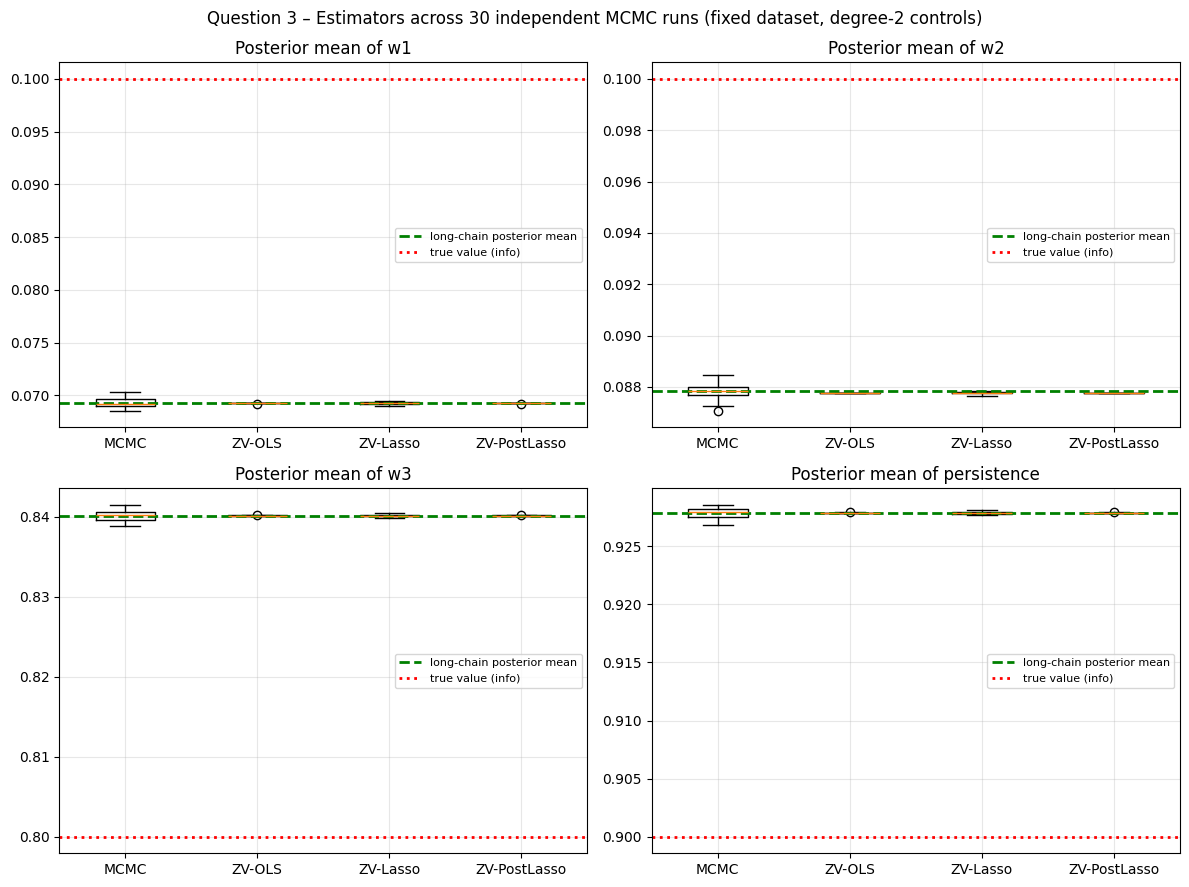

,ref_posterior_mean,MCMC_mean,OLS_mean,Lasso_mean,Post_mean,MCMC_var,OLS_var,Lasso_var,Post_var,VR_OLS,VR_Lasso,VR_PostLasso
w1,0.069265,0.069315,0.069264,0.069253,0.069264,2.200863e-07,2.140615e-10,1.530847e-08,2.140615e-10,1028.144996,14.376762,1028.144996
w2,0.087828,0.087811,0.087776,0.087774,0.087775,9.004761e-08,6.178194e-12,2.495234e-09,6.768447e-12,14575.070177,36.087840,13304.027732
w3,0.840077,0.840039,0.840126,0.840139,0.840126,4.452590e-07,2.921660e-10,3.097498e-08,2.921660e-10,1523.993320,14.374797,1523.993320
persistence,0.927905,0.927851,0.927902,0.927913,0.927902,2.369074e-07,2.310305e-10,1.707305e-08,2.310305e-10,1025.438105,13.876101,1025.438105


,MCMC_bias_vs_ref,OLS_bias_vs_ref,Lasso_bias_vs_ref,Post_bias_vs_ref
w1,0.000050,-0.000002,-0.000012,-0.000002
w2,-0.000017,-0.000052,-0.000055,-0.000053
w3,-0.000038,0.000049,0.000062,0.000049
persistence,-0.000055,-0.000003,0.000008,-0.000003


Average OLS time per regression      : 0.03314110654658483
Average Lasso time per regression    : 13.555846823792672
Average Post-Lasso time per regression: 13.712822218528405


In [ ]:

#Step 4
# Same FIXED dataset as Q2 (r_fixed, built above). Vary only the
# MCMC seed across replications. Compare MCMC vs ZV-OLS / ZV-Lasso /
# ZV-PostLasso on the degree-2 control basis.
import warnings
warnings.filterwarnings("ignore")

n_rep_q3 = 30
target_names_q3 = ["w1", "w2", "w3", "persistence"]
true_targets_q3 = {
    "w1":          float(omega_true[0]),
    "w2":          float(omega_true[1]),
    "w3":          float(omega_true[2]),
    "persistence": float(omega_true[1] + omega_true[2]),
}

mc_runs_q3   = {name: [] for name in target_names_q3}
ols_runs_q3  = {name: [] for name in target_names_q3}
lasso_runs_q3 = {name: [] for name in target_names_q3}
post_runs_q3 = {name: [] for name in target_names_q3}

time_ols_list  = []
time_lasso_list = []
time_post_list = []

for rep in range(n_rep_q3):
    rng_mcmc_rep = np.random.default_rng(8000 + rep)

    chain_rep, acc_rep, _ = adaptive_rwm(
        r=r_fixed,
        prior=prior,
        n_iter=20000,
        omega0=omega0_q3,
        rng=rng_mcmc_rep,
        pilot_iter=2000,
        burn_in=1000,
    )

    Z_rep  = all_z(chain_rep, r_fixed, prior)
    W2_rep = build_controls(chain_rep, Z_rep, degree=2)

    targets_vals = {
        "w1":          chain_rep[:, 0],
        "w2":          chain_rep[:, 1],
        "w3":          chain_rep[:, 2],
        "persistence": chain_rep[:, 1] + chain_rep[:, 2],
    }

    for name in target_names_q3:
        f_rep = targets_vals[name]
        mc_runs_q3[name].append(float(np.mean(f_rep)))

        t0 = time.perf_counter()
        mu_ols_rep, _ = zv_estimator_ols(f_rep, W2_rep)
        time_ols_list.append(time.perf_counter() - t0)
        ols_runs_q3[name].append(mu_ols_rep)

        t0 = time.perf_counter()
        mu_lasso_rep = zv_estimator_lasso(f_rep, W2_rep, cv=3)
        time_lasso_list.append(time.perf_counter() - t0)
        lasso_runs_q3[name].append(mu_lasso_rep)

        t0 = time.perf_counter()
        mu_post_rep = zv_estimator_post_lasso(f_rep, W2_rep, cv=3)
        time_post_list.append(time.perf_counter() - t0)
        post_runs_q3[name].append(mu_post_rep)

mc_runs_q3    = {k: np.asarray(v) for k, v in mc_runs_q3.items()}
ols_runs_q3   = {k: np.asarray(v) for k, v in ols_runs_q3.items()}
lasso_runs_q3 = {k: np.asarray(v) for k, v in lasso_runs_q3.items()}
post_runs_q3  = {k: np.asarray(v) for k, v in post_runs_q3.items()}

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, name in zip(axes.ravel(), target_names_q3):
    ax.boxplot(
        [mc_runs_q3[name], ols_runs_q3[name],
         lasso_runs_q3[name], post_runs_q3[name]],
        labels=["MCMC", "ZV-OLS", "ZV-Lasso", "ZV-PostLasso"],
    )
    ax.axhline(ref_targets[name], color="green", linestyle="--",
               linewidth=2, label="long-chain posterior mean")
    ax.axhline(true_targets_q3[name], color="red", linestyle=":",
               linewidth=2, label="true value (info)")
    ax.set_title(f"Posterior mean of {name}")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", fontsize=8)
fig.suptitle(
    f"Question 3 – Estimators across {n_rep_q3} independent MCMC runs "
    f"(fixed dataset, degree-2 controls)",
    fontsize=12,
)
plt.tight_layout()
plt.show()

# Bias relative to the reference posterior mean (green line)
ratio_table_q3 = pd.DataFrame(
    {
        "ref_posterior_mean": [ref_targets[n] for n in target_names_q3],
        "MCMC_mean":  [mc_runs_q3[n].mean()    for n in target_names_q3],
        "OLS_mean":   [ols_runs_q3[n].mean()   for n in target_names_q3],
        "Lasso_mean": [lasso_runs_q3[n].mean() for n in target_names_q3],
        "Post_mean":  [post_runs_q3[n].mean()  for n in target_names_q3],
        "MCMC_var":   [mc_runs_q3[n].var(ddof=1)    for n in target_names_q3],
        "OLS_var":    [ols_runs_q3[n].var(ddof=1)   for n in target_names_q3],
        "Lasso_var":  [lasso_runs_q3[n].var(ddof=1) for n in target_names_q3],
        "Post_var":   [post_runs_q3[n].var(ddof=1)  for n in target_names_q3],
        "VR_OLS": [
            mc_runs_q3[n].var(ddof=1) / ols_runs_q3[n].var(ddof=1)
            if ols_runs_q3[n].var(ddof=1) > 0 else np.nan
            for n in target_names_q3
        ],
        "VR_Lasso": [
            mc_runs_q3[n].var(ddof=1) / lasso_runs_q3[n].var(ddof=1)
            if lasso_runs_q3[n].var(ddof=1) > 0 else np.nan
            for n in target_names_q3
        ],
        "VR_PostLasso": [
            mc_runs_q3[n].var(ddof=1) / post_runs_q3[n].var(ddof=1)
            if post_runs_q3[n].var(ddof=1) > 0 else np.nan
            for n in target_names_q3
        ],
    },
    index=target_names_q3,
)
display(ratio_table_q3)

# Empirical bias relative to the long-chain reference (the right benchmark)
bias_table_q3 = pd.DataFrame(
    {
        "MCMC_bias_vs_ref":  [mc_runs_q3[n].mean()    - ref_targets[n] for n in target_names_q3],
        "OLS_bias_vs_ref":   [ols_runs_q3[n].mean()   - ref_targets[n] for n in target_names_q3],
        "Lasso_bias_vs_ref": [lasso_runs_q3[n].mean() - ref_targets[n] for n in target_names_q3],
        "Post_bias_vs_ref":  [post_runs_q3[n].mean()  - ref_targets[n] for n in target_names_q3],
    },
    index=target_names_q3,
)
display(bias_table_q3)

print("Average OLS time per regression      :", np.mean(time_ols_list))
print("Average Lasso time per regression    :", np.mean(time_lasso_list))
print("Average Post-Lasso time per regression:", np.mean(time_post_list))

## Question 4 (Bonus) — Validity of Regression on an MCMC Sample

OLS regression implicitly assumes **independent** observations. An MCMC chain produces **correlated** samples, which does not bias the ZV estimator (consistency follows from the ergodic TCL) but **underestimates the standard error** of the OLS coefficients. In other words, $\hat{\beta}$ is correct, but $\text{Var}(\hat{\beta})$ is poorly estimated if the dependence is ignored.

### Strategies to mitigate the problem
1. **Thinning**: retain only one sample every $k$ steps, where $k$ is chosen so that autocorrelation is negligible. Simple but costly in terms of effective sample size.
2. **Batch means**: divide the time series into $B$ blocks of size $m$, and use the block means as i.i.d. pseudo-observations. A good compromise between independence and sample size.
3. **HAC-type standard error** (Newey-West): estimate $\text{Var}(\hat{\beta})$ in a way that is robust to serial correlation without modifying the time series.

In [3]:
# ─────────────────────────────────────────────────────────────
# Bonus — Comparison of raw ZV-OLS vs. subsampled vs. block
# ─────────────────────────────────────────────────────────────

def zv_thinned(chain, Z, W, f_idx=0, thin=5):
    """ ZV-OLS on a thinned chain. """
    ch_ = chain[::thin]; W_ = W[::thin]
    f_  = ch_[:, f_idx]
    mu, _ = zv_estimator_ols(f_, W_)
    return mu


def zv_batch_means(chain, Z, W, f_idx=0, block_size=50):
    """-OLS on block means."""
    N  = len(chain)
    B  = N // block_size
    f_blocks = np.array([chain[b*block_size:(b+1)*block_size, f_idx].mean() for b in range(B)])
    W_blocks = np.array([W[b*block_size:(b+1)*block_size].mean(axis=0)       for b in range(B)])
    mu, _ = zv_estimator_ols(f_blocks, W_blocks)
    return mu


# Illustration using simulated data, parameter ω₁
f_test = chain_q3s[:, 0]
mu_raw    = zv_estimator_ols(f_test, W2_q3s)[0]
mu_thin5  = zv_thinned(chain_q3s, Z_q3s, W2_q3s, f_idx=0, thin=5)
mu_thin10 = zv_thinned(chain_q3s, Z_q3s, W2_q3s, f_idx=0, thin=10)
mu_block  = zv_batch_means(chain_q3s, Z_q3s, W2_q3s, f_idx=0, block_size=100)

print("Bonus — Estimators for ω₁ (simulated data, degree 2)")
print(f'  True value        : {omega_true[0]}')
print(f'  Raw MC             : {f_test.mean():.5f}')
print(f'  Raw ZV-OLS         : {mu_raw:.5f}')
print(f'  ZV-OLS thin=5       : {mu_thin5:.5f}')
print(f'  ZV-OLS thin=10      : {mu_thin10:.5f}')
print(f'  ZV-OLS block (m=100) : {mu_block:.5f}')

NameError: name 'chain_q3s' is not defined

In [ ]:
# Comparaison sur données réelles
if HAS_YFINANCE:
    for fi, nm in enumerate(['w1', 'w2', 'w3']):
        f_  = chain_q3r[:, fi]
        mu0 = zv_estimator_ols(f_, W2_q3r)[0]
        mu5 = zv_thinned(chain_q3r, Z_q3r, W2_q3r, f_idx=fi, thin=5)
        mub = zv_batch_means(chain_q3r, Z_q3r, W2_q3r, f_idx=fi, block_size=100)
        print(f'{nm:4s}  MC={f_.mean():.6f}  ZV-brut={mu0:.6f}  ZV-thin5={mu5:.6f}  ZV-bloc={mub:.6f}')